In [1]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as colors

import getpass
import act

In [65]:
# Note - recommended ARM Live token to be set as an environmental variable

# Check for env variables, otherwise set your username and token here!
if "ARM_USERNAME" in os.environ:
    arm_username = os.getenv("ARM_USERNAME")
else:
    arm_username = input("ARM_USERNAME: ").strip()
if "ARM_TOKEN" in os.environ:
    arm_token = os.getenv("ARM_TOKEN") #token is 600c362367d4b5d1
else:
    arm_token = getpass.getpass("ARM_TOKEN (hidden): ").strip()

# Set the datastream and start/enddates
ef_datastream = 'nsametC1.b1'

startdate = '2015-06-13'
enddate = '2015-06-13'

result_nsametC1 = act.discovery.download_arm_data(arm_username, arm_token, ef_datastream, startdate, enddate)

ARM_USERNAME:  adorough
ARM_TOKEN (hidden):  ········


[DOWNLOADING] nsametC1.b1.20150613.000000.cdf

If you use these data to prepare a publication, please cite:

Kyrouac, J., Shi, Y., & Tuftedal, M. Surface Meteorological Instrumentation
(MET), 2015-06-13 to 2015-06-13, North Slope Alaska (NSA), Central Facility,
Barrow AK (C1). Atmospheric Radiation Measurement (ARM) User Facility.
https://doi.org/10.5439/1786358



In [66]:
ds_met = act.io.read_arm_netcdf(result_nsametC1)

ds_met

<xarray.Dataset> Size: 374kB
Dimensions:                       (time: 1440)
Coordinates:
  * time                          (time) datetime64[ns] 12kB 2015-06-13 ... 2...
Data variables: (12/59)
    base_time                     datetime64[ns] 8B 2015-06-13
    time_offset                   (time) datetime64[ns] 12kB 2015-06-13 ... 2...
    atmos_pressure                (time) float32 6kB dask.array<chunksize=(1440,), meta=np.ndarray>
    qc_atmos_pressure             (time) int32 6kB dask.array<chunksize=(1440,), meta=np.ndarray>
    temp_mean                     (time) float32 6kB dask.array<chunksize=(1440,), meta=np.ndarray>
    qc_temp_mean                  (time) int32 6kB dask.array<chunksize=(1440,), meta=np.ndarray>
    ...                            ...
    qc_logger_volt                (time) int32 6kB dask.array<chunksize=(1440,), meta=np.ndarray>
    logger_temp                   (time) float32 6kB dask.array<chunksize=(1440,), meta=np.ndarray>
    qc_logger_temp                (time) int32 6kB dask.array<chunksize=(1440,), meta=np.ndarray>
    lat                           float32 4B ...
    lon                           float32 4B ...
    alt                           float32 4B ...
Attributes: (12/32)
    command_line:                 met_ingest -s nsa -f C1
    process_version:              ingest-met-4.29-0.el6
    dod_version:                  met-b1-6.2
    input_source:                 /data/collection/nsa/nsametC1.00/METData.20...
    site_id:                      nsa
    platform_id:                  met
    ...                           ...
    qc_bit_4_assessment:          Indeterminate
    history:                      created by user dsmgr on machine ruby at 20...
    _file_dates:                  ['20150613']
    _file_times:                  ['000000']
    _datastream:                  nsametC1.b1
    _arm_standards_flag:          1

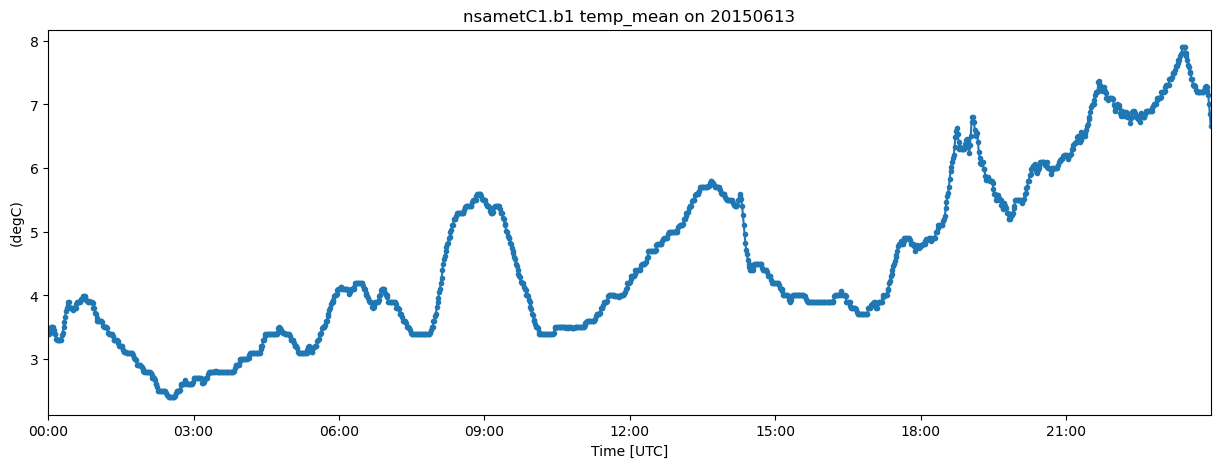

In [67]:
ds_met['temp_mean'] = ds_met['temp_mean'].where(ds_met['temp_mean']!=-9999)

display = act.plotting.TimeSeriesDisplay(ds_met, subplot_shape=(1,), figsize=(15, 5))
display.plot('temp_mean', subplot_index=(0,), cvd_friendly=True)
plt.show()

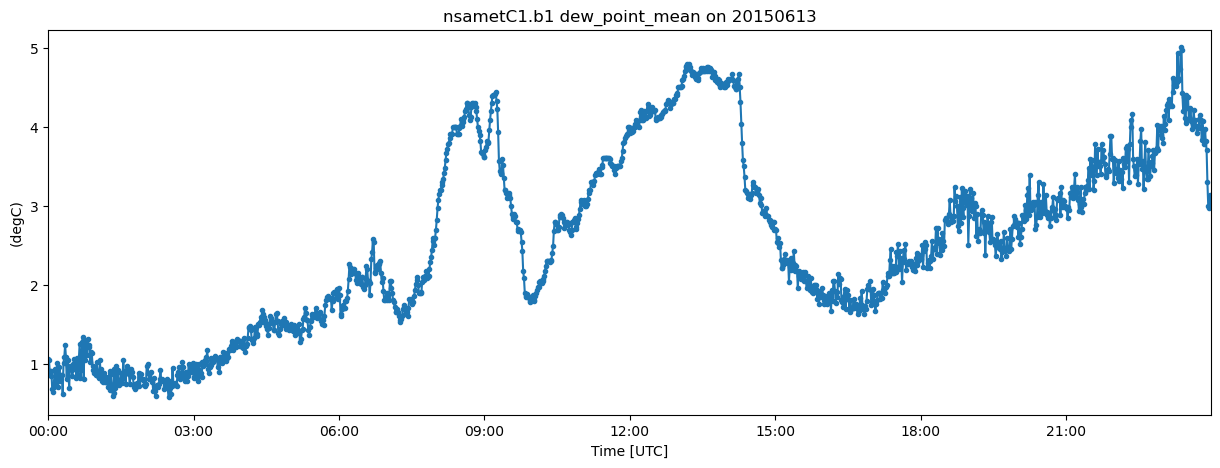

In [68]:
ds_met['dew_point_mean'] = ds_met['dew_point_mean'].where(ds_met['dew_point_mean']!=-9999)

display = act.plotting.TimeSeriesDisplay(ds_met, subplot_shape=(1,), figsize=(15, 5))
display.plot('dew_point_mean', subplot_index=(0,), cvd_friendly=True)
plt.show()

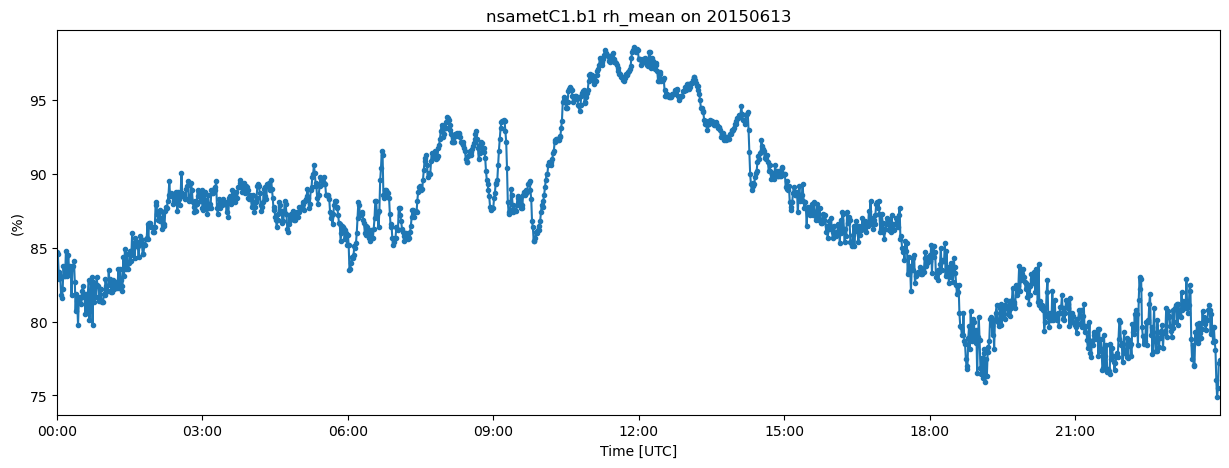

In [69]:
display = act.plotting.TimeSeriesDisplay(ds_met, subplot_shape=(1,), figsize=(15,5))
display.plot('rh_mean', subplot_index=(0,), cvd_friendly=True)
plt.show()

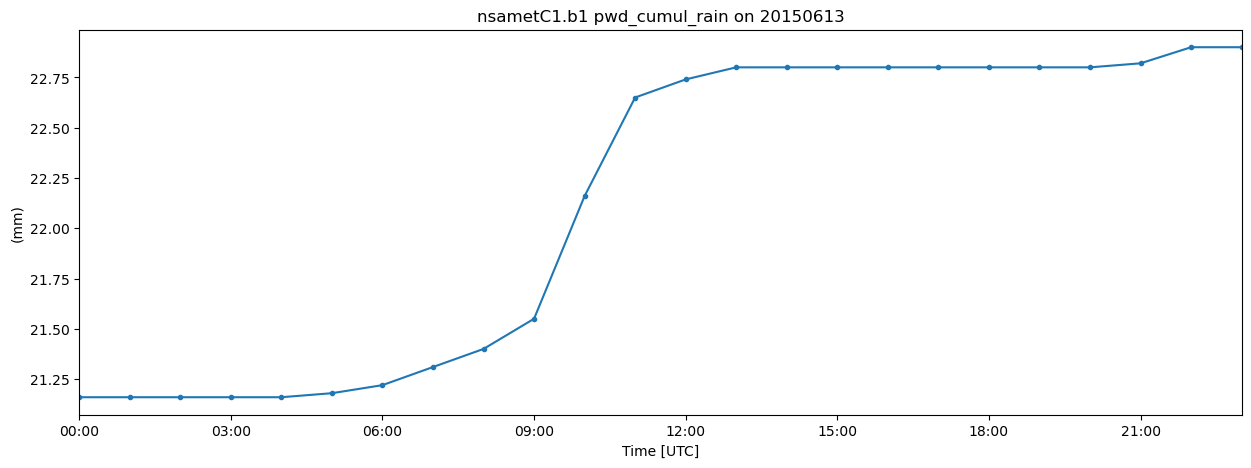

In [70]:
hourly_ds = ds_met.resample(time='1h').max()

display = act.plotting.TimeSeriesDisplay(hourly_ds, subplot_shape=(1,), figsize=(15, 5))
display.plot('pwd_cumul_rain', subplot_index=(0,), cvd_friendly=True)
plt.show()

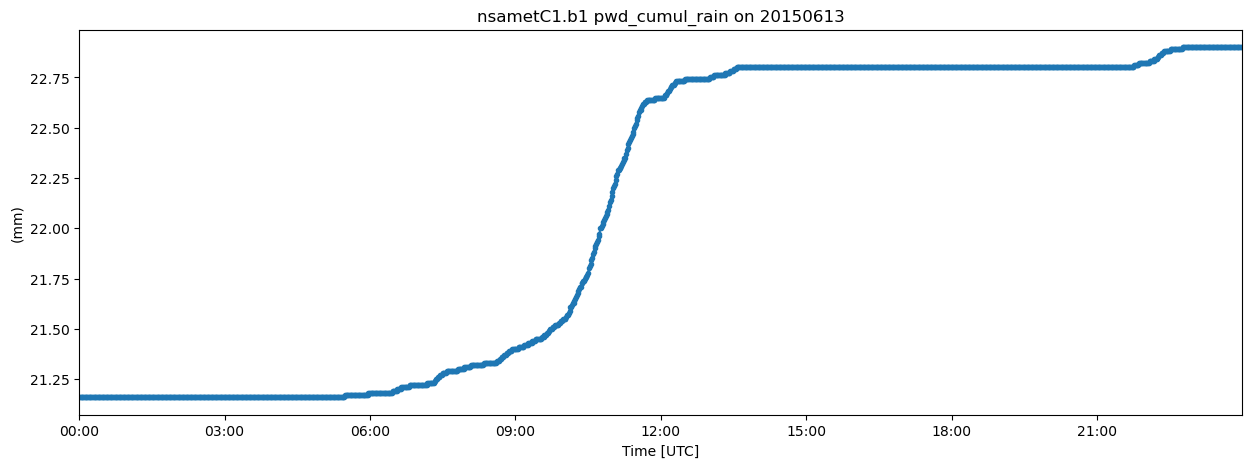

In [71]:
display = act.plotting.TimeSeriesDisplay(ds_met, subplot_shape=(1,), figsize=(15, 5))
display.plot('pwd_cumul_rain', subplot_index=(0,), cvd_friendly=True)
plt.show()

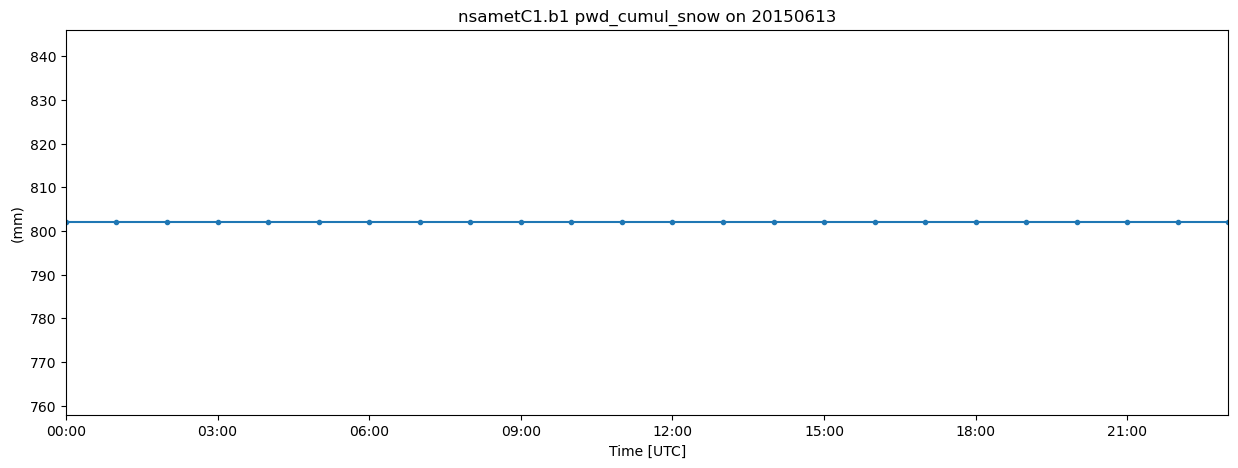

In [72]:
display = act.plotting.TimeSeriesDisplay(hourly_ds, subplot_shape=(1,), figsize=(15, 5))
display.plot('pwd_cumul_snow', subplot_index=(0,), cvd_friendly=True)
plt.show()

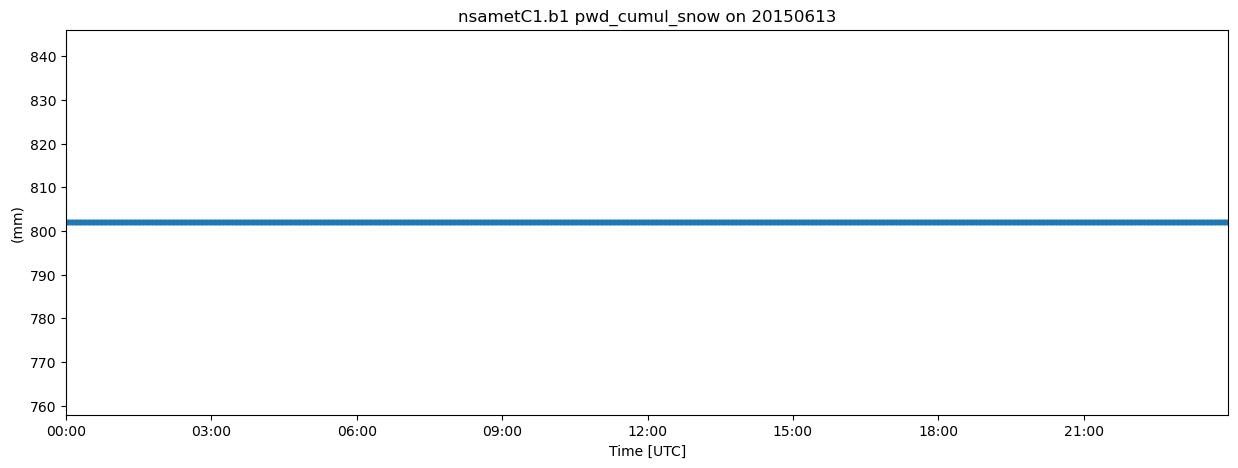

In [73]:
display = act.plotting.TimeSeriesDisplay(ds_met, subplot_shape=(1,), figsize=(15, 5))
display.plot('pwd_cumul_snow', subplot_index=(0,), cvd_friendly=True)
plt.show()

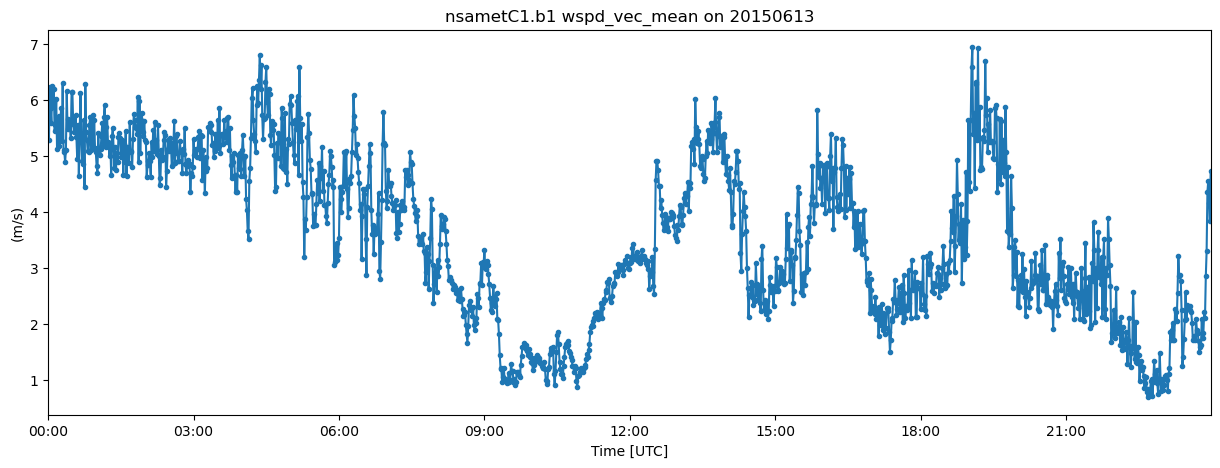

In [74]:
display = act.plotting.TimeSeriesDisplay(ds_met, subplot_shape=(1,), figsize=(15, 5))
display.plot('wspd_vec_mean', subplot_index=(0,), cvd_friendly=True)
plt.show()

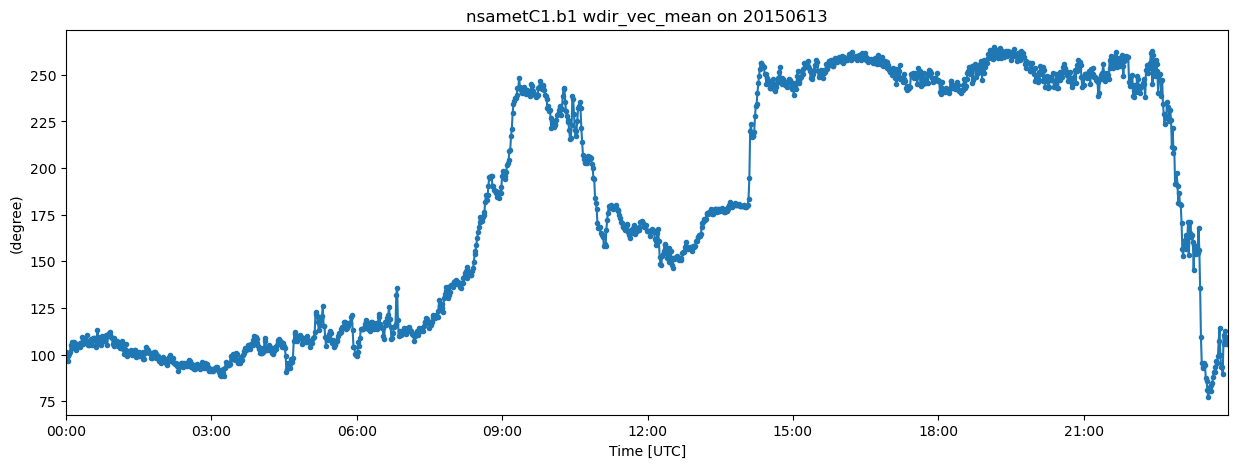

In [75]:
display = act.plotting.TimeSeriesDisplay(ds_met, subplot_shape=(1,), figsize=(15, 5))
display.plot('wdir_vec_mean', subplot_index=(0,), cvd_friendly=True)
plt.show()

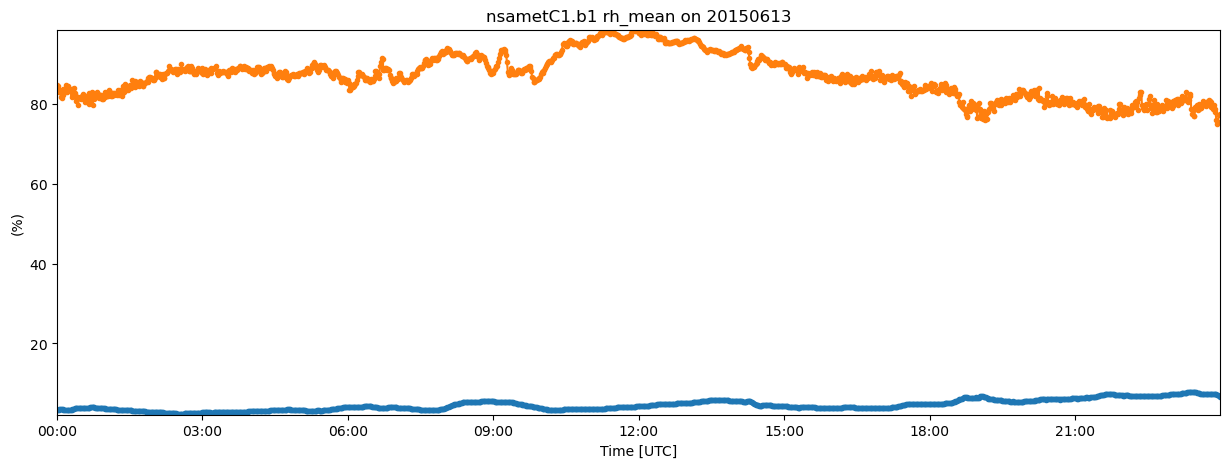

In [76]:
display = act.plotting.TimeSeriesDisplay(ds_met, subplot_shape=(1,), figsize=(15, 5))
display.plot('temp_mean', subplot_index=(0,), cvd_friendly=True)
display.plot('rh_mean', subplot_index=(0,), cvd_friendly=True)
plt.show()